# Modélisation baseline



## Partie A : Import de fonctions utiles à la modélisation baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions/modelisations"))

%load_ext autoreload
%autoreload 2

from baseline import *

## Partie B : Paramètres fixes et nettoyage de variables

In [2]:
# Chargement des données

df_train = pd.read_csv(r"..\data_finale\featuring\train_featured.csv", encoding="utf-8-sig")
df_val   = pd.read_csv(r"..\data_finale\featuring\val_featured.csv", encoding="utf-8-sig")

# Sélection de la cible (Y) et des 3 variables naïves (X)

X_cols_naives = ["Performance_Gls", "Playing Time_MP", "log_prev_value"]
target_col = "market_value_in_eur"

In [3]:
df_train_clean, df_val_clean = nettoyer_donnees_manquantes(df_train, df_val, X_cols_naives, target_col)

Lignes après suppression des NA -> Train: 7404 (vs 7404) | Val: 2431 (vs 2431)



In [4]:
# On extrait du jeu d'entraînement uniquement les colonnes de performance choisies
X_train = df_train_clean[X_cols_naives]

# On extrait la colonne que le modèle doit apprendre à prédire (la valeur marchande réelle)
y_train = df_train_clean[target_col]

# On effectue exactement la même séparation sur le jeu de validation
X_val = df_val_clean[X_cols_naives]
y_val = df_val_clean[target_col]

print(f"Variables utilisées pour le modèle naïf : {X_cols_naives}")
print(f"Variable cible : {target_col}\n")

Variables utilisées pour le modèle naïf : ['Performance_Gls', 'Playing Time_MP', 'log_prev_value']
Variable cible : market_value_in_eur



## Partie C : Régression linéaire simple

### C1 : Entraînement du modèle

In [5]:
# Entraînement de la régression linéaire
modele_naif = LinearRegression()
modele_naif.fit(X_train, y_train)

# Prédictions sur le jeu d'entraînement et de validation
y_pred_train = modele_naif.predict(X_train)
y_pred_val = modele_naif.predict(X_val)

### C2 : Performances du modèle

In [6]:
# Calcul des métriques de performance et affichage

mae_train, rmse_train, r2_train = calculer_metriques(y_train, y_pred_train)
mae_val, rmse_val, r2_val = calculer_metriques(y_val, y_pred_val)

affichage_performances(mae_train, rmse_train, r2_train, mae_val, rmse_val, r2_val)

Performances du modèle naïf (baseline)

Jeu d'entraînement (train)
- MAE  (Erreur Moyenne Absolue) : 7,384,811.62 €
- RMSE (Écart-type des erreurs) : 11,531,556.76 €
- R²   (Pouvoir explicatif)     : 0.4491 (44.9%)

Jeu de validation (val)
- MAE  (Erreur Moyenne Absolue) : 7,543,337.72 €
- RMSE (Écart-type des erreurs) : 12,637,051.82 €
- R²   (Pouvoir explicatif)     : 0.5069 (50.7%)


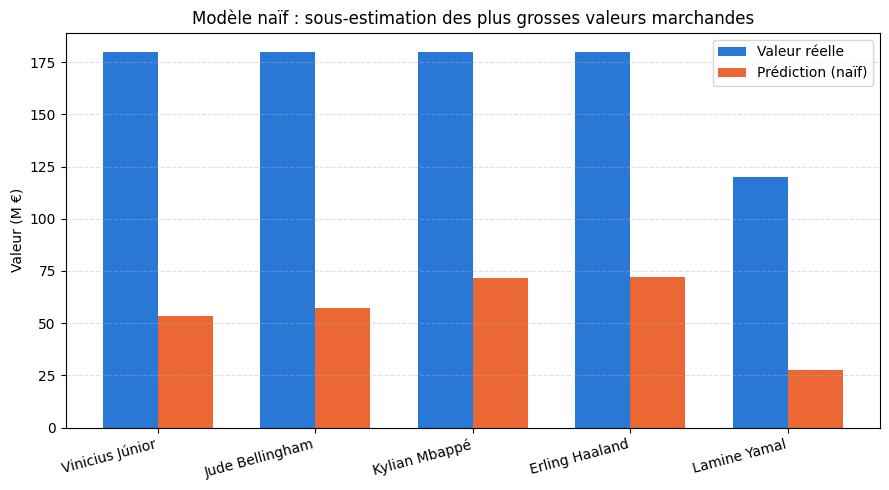

,Joueur,Saison,Valeur Réelle,Prédiction,Erreur (Ecart)
2301,Vinicius Júnior,2023,180000000.0,5.324045e+07,1.267596e+08
1173,Jude Bellingham,2023,180000000.0,5.742741e+07,1.225726e+08
1288,Kylian Mbappé,2023,180000000.0,7.177234e+07,1.082277e+08
658,Erling Haaland,2023,180000000.0,7.214171e+07,1.078583e+08
1295,Lamine Yamal,2023,120000000.0,2.772816e+07,9.227184e+07


In [7]:
afficher_top_erreurs_predictions(df_val_clean, y_val, y_pred_val, top_n=5)

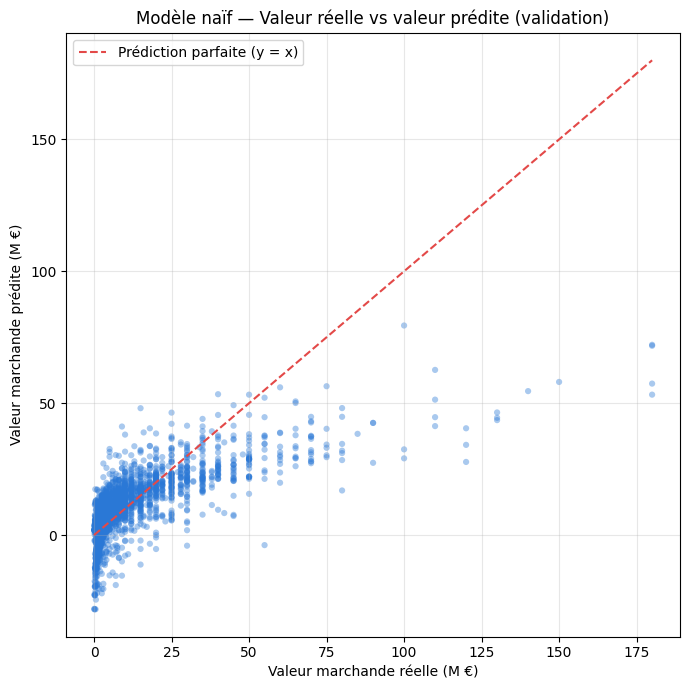

In [8]:
afficher_scatter_reelle_vs_predite(y_val, y_pred_val)